In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


# DenseNet Architecture Study

In this section, we study the DenseNet architecture and investigate how two important architectural properties affect its performance on the CIFAR-10 classification task.

The experiments will focus on:

1. **Depth** — changing the number of layers in the dense blocks.
2. **Growth Rate** — changing the number of new feature maps produced by each dense layer.

The main idea behind DenseNet is that each layer receives the feature maps produced by all previous layers through **concatenation**. This allows later layers to reuse features learned by earlier layers.

The experiments will be designed so that only one architectural variable is changed at a time while the other conditions remain fixed.

## Experiment 1 — Depth

In the first experiment, the growth rate will be kept constant while the number of layers in the dense blocks is changed.

The models will use:

- DenseNet2 — 2 layers per dense block
- DenseNet3 — 3 layers per dense block
- DenseNet4 — 4 layers per dense block

The growth rate and the rest of the architecture will remain constant across the three models.

The purpose of this experiment is to investigate how increasing the number of layers affects the model's ability to learn and generalize.

## Experiment 2 — Growth Rate

In the second experiment, the number of layers in the dense blocks will be kept constant while the growth rate is changed.

The models will use:

- DenseNet3-Narrow — growth rate of 8
- DenseNet3-Base — growth rate of 16
- DenseNet3-Wide — growth rate of 24

The number of dense layers and the rest of the architecture will remain constant across the three models.

The purpose of this experiment is to investigate how increasing the number of new feature maps produced by each dense layer affects the model's learning and generalization performance.

## Controlled Conditions

The following conditions will remain constant throughout both experiments:

- Dataset: CIFAR-10
- Input size: `32×32`
- Batch size: 64
- Epochs: 20
- Optimizer: SGD
- Learning rate: 0.01
- Momentum: 0.9
- Loss function: CrossEntropyLoss
- Training augmentation: Random Horizontal Flip
- CIFAR-10 normalization
- Same training, validation, and test datasets

The purpose of the study is not simply to obtain the highest accuracy, but to understand how **depth and growth rate affect the behavior of a DenseNet architecture** under controlled conditions.

In [3]:
!git clone https://github.com/davidmba819/cnn-architecture-study

Cloning into 'cnn-architecture-study'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 49 (delta 19), reused 28 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 2.85 MiB | 12.16 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [4]:
%cd /kaggle/working/cnn-architecture-study

/kaggle/working/cnn-architecture-study


In [5]:
import sys

sys.path.append("/kaggle/working/cnn-architecture-study")

import cnn_utils

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets

In [7]:
DATA_DIR = "/kaggle/input/datasets/pankrzysiu/cifar10-python"

In [8]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=None
)

In [9]:
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


In [10]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [11]:
print(train_transform)
print(eval_transform)


Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)
Compose(
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)


In [12]:
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [13]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data=train_data,
    val_data=val_data,
    test_data=test_dataset,
    train_transform=train_transform,
    eval_transform=eval_transform,
    batch_size=64,
    num_workers=2
)

In [14]:
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")


Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [15]:
class DenseLayer(nn.Module):

    def __init__(self, in_channels, growth_rate):
        super().__init__()

        self.bn = nn.BatchNorm2d(in_channels)

        self.relu = nn.ReLU()

        self.conv = nn.Conv2d(
            in_channels,
            growth_rate,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self._initialize_weights()

    def _initialize_weights(self):

        nn.init.kaiming_normal_(
            self.conv.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

    def forward(self, x):

        out = self.bn(x)
        out = self.relu(out)
        out = self.conv(out)

        return out

In [16]:
class DenseBlock(nn.Module):

    def __init__(self, in_channels, num_layers, growth_rate):
        super().__init__()

        layers = []

        current_channels = in_channels

        for _ in range(num_layers):

            layers.append(
                DenseLayer(
                    in_channels=current_channels,
                    growth_rate=growth_rate
                )
            )

            current_channels += growth_rate

        self.layers = nn.ModuleList(layers)

    def forward(self, x):

        features = [x]

        for layer in self.layers:

            new_features = layer(torch.cat(features, dim=1))

            features.append(new_features)

        return torch.cat(features, dim=1)

In [17]:
class TransitionLayer(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.bn = nn.BatchNorm2d(in_channels)

        self.relu = nn.ReLU()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )

        self.pool = nn.AvgPool2d(
            kernel_size=2,
            stride=2
        )

        self._initialize_weights()

    def _initialize_weights(self):

        nn.init.kaiming_normal_(
            self.conv.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

    def forward(self, x):

        x = self.bn(x)
        x = self.relu(x)
        x = self.conv(x)
        x = self.pool(x)

        return x

In [18]:
class DenseNet(nn.Module):

    def __init__(
        self,
        num_blocks=3,
        num_layers=3,
        growth_rate=16,
        init_channels=64
    ):
        super().__init__()

        self.initial = nn.Conv2d(
            in_channels=3,
            out_channels=init_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.blocks = nn.ModuleList()
        self.transitions = nn.ModuleList()

        current_channels = init_channels

        for block_index in range(num_blocks):

            block = DenseBlock(
                in_channels=current_channels,
                num_layers=num_layers,
                growth_rate=growth_rate
            )

            self.blocks.append(block)

            current_channels += num_layers * growth_rate

            if block_index < num_blocks - 1:

                out_channels = current_channels // 2

                transition = TransitionLayer(
                    in_channels=current_channels,
                    out_channels=out_channels
                )

                self.transitions.append(transition)

                current_channels = out_channels

        self.classifier = nn.Sequential(
            nn.BatchNorm2d(current_channels),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(current_channels, 10)
        )

        self._initialize_weights()

    def _initialize_weights(self):

        nn.init.kaiming_normal_(
            self.initial.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        nn.init.xavier_normal_(
            self.classifier[4].weight
        )

        nn.init.zeros_(
            self.classifier[4].bias
        )

    def forward(self, x):

        x = self.initial(x)

        for i, block in enumerate(self.blocks):

            x = block(x)

            if i < len(self.transitions):
                x = self.transitions[i](x)

        x = self.classifier(x)

        return x

In [19]:
x = torch.randn(64, 64, 32, 32)

dense_block = DenseBlock(
    in_channels=64,
    num_layers=3,
    growth_rate=16
)

output = dense_block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 64, 32, 32])
Output shape: torch.Size([64, 112, 32, 32])


In [20]:
transition = TransitionLayer(
    in_channels=112,
    out_channels=56
)

transition_output = transition(output)

print("Before transition:", output.shape)
print("After transition:", transition_output.shape)

Before transition: torch.Size([64, 112, 32, 32])
After transition: torch.Size([64, 56, 16, 16])


In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


In [22]:
model = DenseNet(
    num_layers=3,
    growth_rate=16,
    init_channels=64
)

x = torch.randn(64, 3, 32, 32)

output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [23]:
print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(80, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(96, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
        

# Experiment 1 — Depth

The first DenseNet experiment investigates the effect of **network depth**, measured by the number of DenseBlocks in the network.

DenseNet is organized as a sequence of DenseBlocks separated by TransitionLayers. Each DenseBlock contains multiple DenseLayers, but in this experiment the number of DenseLayers inside each block is kept constant. The architectural variable is the **number of DenseBlocks**.

### Experimental configurations

| Model | Dense Blocks | Layers per Block | Growth Rate | Initial Channels |
|---|---:|---:|---:|---:|
| DenseNet2 | 2 | 3 | 16 | 64 |
| DenseNet3 | 3 | 3 | 16 | 64 |
| DenseNet4 | 4 | 3 | 16 | 64 |

### Controlled variables

The following settings are kept constant across all three models:

- Dataset: CIFAR-10
- Input size: 32 × 32 RGB images
- Layers per DenseBlock: 3
- Growth rate: 16
- Initial channels: 64
- Batch size: 64
- Optimizer: SGD
- Learning rate: 0.01
- Momentum: 0.9
- Loss function: CrossEntropyLoss
- Epochs: 20
- Training augmentation: RandomHorizontalFlip
- Official CIFAR-10 test set: kept untouched until final evaluation

### What this experiment investigates

The main question is:

> **How does increasing the number of DenseBlocks affect DenseNet's classification performance?**

The experiment compares the training, validation, and test performance of networks with 2, 3, and 4 DenseBlocks.

Because the number of DenseLayers per block and the growth rate remain fixed, differences between the models are primarily associated with increasing the depth of the overall DenseNet architecture.

### Model Configuration

Each model follows the same DenseNet building pattern:

```text
Initial Convolution
        ↓
Dense Block
        ↓
Transition
        ↓
Dense Block
        ↓
Transition
        ↓
...
        ↓
Dense Block
        ↓
Global Average Pooling
        ↓
Classifier

In [24]:
for num_blocks in [2, 3, 4]:

    model = DenseNet(
        num_blocks=num_blocks,
        num_layers=3,
        growth_rate=16,
        init_channels=64
    )

    x = torch.randn(4, 3, 32, 32)
    output = model(x)

    print(
        f"DenseNet{num_blocks}:",
        "Blocks =", len(model.blocks),
        "| Transitions =", len(model.transitions),
        "| Output =", output.shape
    )

DenseNet2: Blocks = 2 | Transitions = 1 | Output = torch.Size([4, 10])
DenseNet3: Blocks = 3 | Transitions = 2 | Output = torch.Size([4, 10])
DenseNet4: Blocks = 4 | Transitions = 3 | Output = torch.Size([4, 10])


### DenseNet2 — 2 Dense Blocks

DenseNet2 is the first model in the depth experiment. It contains **2 DenseBlocks**, with each block containing **3 DenseLayers**.

The growth rate is fixed at 16 and the initial number of channels is fixed at 64. These values remain unchanged throughout the depth experiment.

The architecture is:

```text
Input: 3 × 32 × 32
        ↓
Initial 3×3 Convolution
        ↓
Dense Block 1
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 2
  3 DenseLayers
        ↓
BatchNorm + ReLU
        ↓
Global Average Pooling
        ↓
Linear Classifier
        ↓
10 Classes

In [25]:

## Create DenseNet2

model = DenseNet(
    num_blocks=2,
    num_layers=3,
    growth_rate=16,
    init_channels=64
)

print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(80, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(96, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
        

In [26]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [27]:
model, history_densenet2 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7542 | Train Acc: 0.3538 | Val Loss: 1.5866 | Val Acc: 0.4131
Epoch [2/20] Train Loss: 1.4775 | Train Acc: 0.4603 | Val Loss: 1.3877 | Val Acc: 0.4983
Epoch [3/20] Train Loss: 1.3233 | Train Acc: 0.5222 | Val Loss: 1.2471 | Val Acc: 0.5434
Epoch [4/20] Train Loss: 1.2309 | Train Acc: 0.5577 | Val Loss: 1.1583 | Val Acc: 0.5768
Epoch [5/20] Train Loss: 1.1547 | Train Acc: 0.5867 | Val Loss: 1.2321 | Val Acc: 0.5729
Epoch [6/20] Train Loss: 1.0914 | Train Acc: 0.6091 | Val Loss: 1.0537 | Val Acc: 0.6177
Epoch [7/20] Train Loss: 1.0377 | Train Acc: 0.6319 | Val Loss: 1.0427 | Val Acc: 0.6352
Epoch [8/20] Train Loss: 1.0013 | Train Acc: 0.6427 | Val Loss: 1.0259 | Val Acc: 0.6387
Epoch [9/20] Train Loss: 0.9581 | Train Acc: 0.6592 | Val Loss: 1.1491 | Val Acc: 0.5901
Epoch [10/20] Train Loss: 0.9240 | Train Acc: 0.6699 | Val Loss: 0.9167 | Val Acc: 0.6692
Epoch [11/20] Train Loss: 0.8966 | Train Acc: 0.6793 | Val Loss: 1.0152 | Val Acc: 0.6450
Epoch [12/20] Train

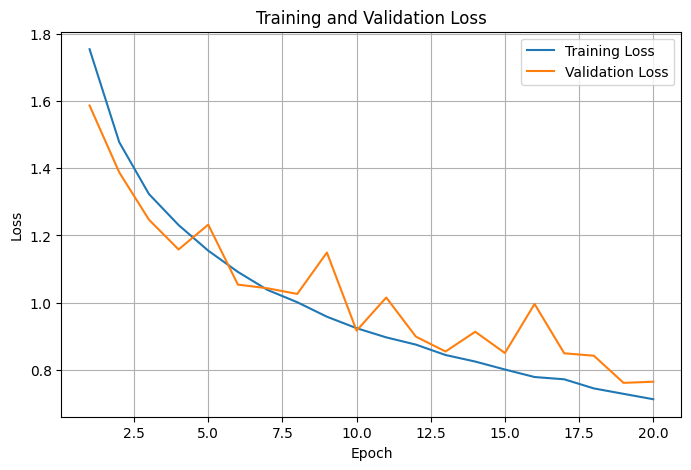

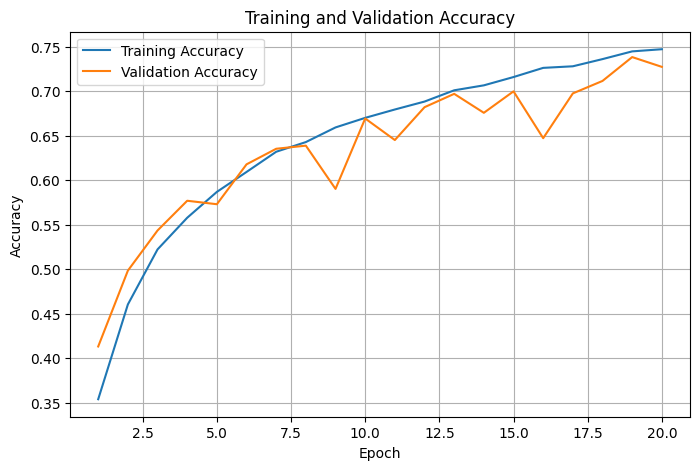

In [28]:
cnn_utils.plot_history(history_densenet2)

In [29]:
test_loss_densenet2, test_accuracy_densenet2 = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss_densenet2:.4f}")
print(f"Test Accuracy: {test_accuracy_densenet2:.2f}%")

Test Loss: 0.7808
Test Accuracy: 0.7263
Test Loss: 0.7808
Test Accuracy: 0.73%


### DenseNet2 — Results and Analysis

DenseNet2 was trained with **2 DenseBlocks**, with **3 DenseLayers in each block**. The growth rate was kept at **16**, while the initial number of channels was fixed at **64**. The model was trained for 20 epochs using the same training configuration used throughout the CNN architecture study.

The model started with a training accuracy of **35.38%** in the first epoch and a validation accuracy of **41.31%**. As training progressed, both training and validation accuracy generally increased. By epoch 10, the training accuracy had reached **66.99%**, while the validation accuracy was **66.92%**. By the final epoch, the training accuracy increased further to **74.70%**, while the validation accuracy reached **72.72%**.

The loss curves show a similar overall pattern. Training loss decreased from **1.7542** in the first epoch to **0.7126** at epoch 20. Validation loss also decreased from **1.5866** initially to **0.7646** at the end of training. Although the validation loss fluctuated throughout training, the overall direction was downward.

One noticeable part of the training curves is that the validation performance did not increase smoothly from one epoch to the next. For example, the validation loss increased from **0.9217 at epoch 10** to **1.0158 at epoch 11**, before falling again in the following epochs. Similar fluctuations can be seen in the validation accuracy. These changes did not prevent the model from improving overall, but they show that the validation performance was less stable than the training performance.

The final training and validation results were:

| Metric | Training | Validation |
|---|---:|---:|
| Loss | 0.7126 | 0.7646 |
| Accuracy | 74.70% | 72.72% |

The difference between the final training accuracy and validation accuracy was approximately **1.98 percentage points**. This is a relatively small gap compared with the much larger gaps observed in some of the deeper architectures from the previous CNN experiments. The curves therefore do not show a strong separation between training and validation performance at the end of training.

After training was completed, the model was evaluated on the **untouched CIFAR-10 test set**. DenseNet2 obtained a test loss of **0.7808** and a test accuracy of **72.63%**.

The test accuracy is very close to the final validation accuracy:

- Validation accuracy: **72.72%**
- Test accuracy: **72.63%**
- Difference: **0.09 percentage points**

This small difference suggests that the validation result gave a fairly close indication of how DenseNet2 performed on the held-out test set under these experimental conditions.

Overall, DenseNet2 provides the starting point for the depth experiment. With only two DenseBlocks, the model reached **72.63% test accuracy** after 20 epochs. The important comparison will therefore be with DenseNet3 and DenseNet4. Since the number of DenseLayers per block and the growth rate will remain fixed, adding more DenseBlocks will allow us to observe whether increasing the overall depth of the DenseNet architecture produces a corresponding improvement in test performance, or whether the additional depth eventually gives diminishing returns or increases overfitting.

### DenseNet3 — 3 Dense Blocks

DenseNet3 is the second model in the depth experiment. It contains **3 DenseBlocks**, with each block containing **3 DenseLayers**.

The growth rate remains fixed at **16**, and the initial number of channels remains **64**. Therefore, compared with DenseNet2, the only architectural change is the addition of one more DenseBlock.

The architecture is:

```text
Input: 3 × 32 × 32
        ↓
Initial 3×3 Convolution
        ↓
Dense Block 1
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 2
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 3
  3 DenseLayers
        ↓
BatchNorm + ReLU
        ↓
Global Average Pooling
        ↓
Linear Classifier
        ↓
10 Classes

In [30]:

## Create DenseNet3


model = DenseNet(
    num_blocks=3,
    num_layers=3,
    growth_rate=16,
    init_channels=64
)

print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(80, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(96, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
        

In [31]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [32]:
model, history_densenet3 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6877 | Train Acc: 0.3819 | Val Loss: 1.4799 | Val Acc: 0.4618
Epoch [2/20] Train Loss: 1.3577 | Train Acc: 0.5061 | Val Loss: 1.3186 | Val Acc: 0.5294
Epoch [3/20] Train Loss: 1.2006 | Train Acc: 0.5674 | Val Loss: 1.1190 | Val Acc: 0.5973
Epoch [4/20] Train Loss: 1.0858 | Train Acc: 0.6129 | Val Loss: 1.0506 | Val Acc: 0.6243
Epoch [5/20] Train Loss: 1.0086 | Train Acc: 0.6403 | Val Loss: 1.0023 | Val Acc: 0.6351
Epoch [6/20] Train Loss: 0.9391 | Train Acc: 0.6650 | Val Loss: 0.9411 | Val Acc: 0.6686
Epoch [7/20] Train Loss: 0.8851 | Train Acc: 0.6847 | Val Loss: 0.8854 | Val Acc: 0.6830
Epoch [8/20] Train Loss: 0.8369 | Train Acc: 0.7025 | Val Loss: 0.8799 | Val Acc: 0.6927
Epoch [9/20] Train Loss: 0.7982 | Train Acc: 0.7151 | Val Loss: 0.8225 | Val Acc: 0.7031
Epoch [10/20] Train Loss: 0.7620 | Train Acc: 0.7287 | Val Loss: 0.8006 | Val Acc: 0.7154
Epoch [11/20] Train Loss: 0.7266 | Train Acc: 0.7435 | Val Loss: 0.7731 | Val Acc: 0.7258
Epoch [12/20] Train

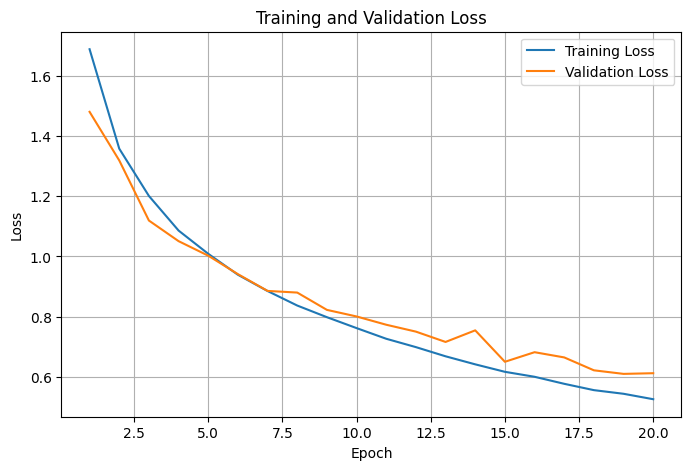

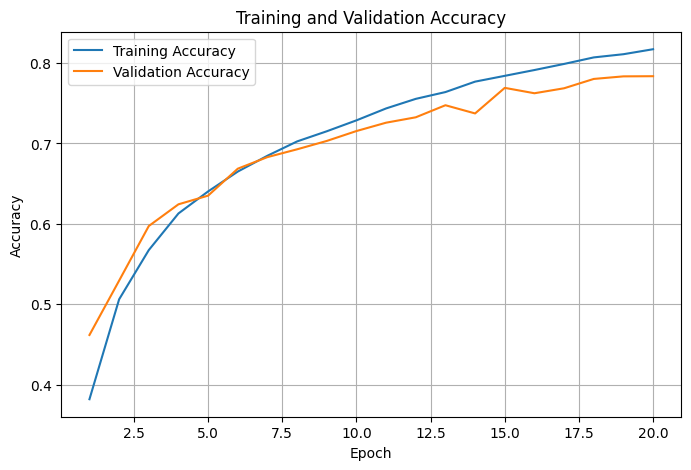

In [33]:
cnn_utils.plot_history(history_densenet3)

In [34]:
test_loss_densenet3, test_accuracy_densenet3 = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss_densenet3:.4f}")
print(f"Test Accuracy: {test_accuracy_densenet3:.2f}%")

Test Loss: 0.6204
Test Accuracy: 0.7840
Test Loss: 0.6204
Test Accuracy: 0.78%


### DenseNet3 — Results and Analysis

DenseNet3 was trained with **3 DenseBlocks**, with each block containing **3 DenseLayers**. The growth rate was kept at **16** and the initial number of channels was fixed at **64**. The model was trained for 20 epochs using the same training configuration as DenseNet2.

The model started with a training accuracy of **38.19%** in the first epoch and a validation accuracy of **46.18%**. Both values increased consistently as training progressed. By epoch 10, the training accuracy had reached **72.87%**, while the validation accuracy was **71.54%**. At the end of epoch 20, the training accuracy reached **81.72%**, while the validation accuracy reached **78.36%**.

The training loss decreased from **1.6877** in the first epoch to **0.5259** at epoch 20. Validation loss also decreased from **1.4799** to **0.6122**. Unlike DenseNet2, where the validation loss showed several noticeable fluctuations throughout training, the DenseNet3 validation loss followed a more consistent downward trend, although there were still some increases around the later epochs.

The accuracy curves also show a steady improvement. Training accuracy remained above validation accuracy during most of the later epochs, but the two curves remained reasonably close. At epoch 20, the difference between training and validation accuracy was:

**81.72% − 78.36% = 3.36 percentage points.**

This indicates that the additional DenseBlock allowed the model to fit the training data better than DenseNet2, while still maintaining relatively close validation performance.

The final training and validation results were:

| Metric | Training | Validation |
|---|---:|---:|
| Loss | 0.5259 | 0.6122 |
| Accuracy | 81.72% | 78.36% |

The model was then evaluated on the untouched CIFAR-10 test set. DenseNet3 achieved a **test loss of 0.6204** and a **test accuracy of 78.40%**.

The validation and test accuracies were almost identical:

- Validation accuracy: **78.36%**
- Test accuracy: **78.40%**
- Difference: **0.04 percentage points**

This is a very small difference, showing that the validation result closely represented the model's performance on the unseen test set for this run.

More importantly, comparing DenseNet3 with DenseNet2 shows a clear change from adding one DenseBlock:

| Model | Dense Blocks | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet2 | 2 | 74.70% | 72.72% | 72.63% |
| DenseNet3 | 3 | 81.72% | 78.36% | 78.40% |

DenseNet3 improved the test accuracy from **72.63% to 78.40%**, which is an increase of **5.77 percentage points**.

The training accuracy also increased by **7.02 percentage points**, from 74.70% to 81.72%, while validation accuracy increased by **5.64 percentage points**, from 72.72% to 78.36%.

At this stage of the experiment, adding the third DenseBlock therefore produced a substantial improvement in both training and held-out performance. The next model, DenseNet4, will show whether adding another DenseBlock continues this improvement or whether the additional depth begins to provide smaller gains or introduce a larger training-validation gap.

### DenseNet4 — 4 Dense Blocks

DenseNet4 is the third and final model in the depth experiment. It contains **4 DenseBlocks**, with each block containing **3 DenseLayers**.

The growth rate remains fixed at **16**, and the initial number of channels remains **64**. Therefore, compared with DenseNet3, the only architectural change is the addition of a fourth DenseBlock.

The architecture is:

```text
Input: 3 × 32 × 32
        ↓
Initial 3×3 Convolution
        ↓
Dense Block 1
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 2
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 3
  3 DenseLayers
        ↓
Transition Layer
        ↓
Dense Block 4
  3 DenseLayers
        ↓
BatchNorm + ReLU
        ↓
Global Average Pooling
        ↓
Linear Classifier
        ↓
10 Classes

In [35]:

## Create DenseNet4


model = DenseNet(
    num_blocks=4,
    num_layers=3,
    growth_rate=16,
    init_channels=64
)

print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(80, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(96, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
        

In [36]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)


In [37]:
model, history_densenet4 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6051 | Train Acc: 0.4083 | Val Loss: 1.4160 | Val Acc: 0.4816
Epoch [2/20] Train Loss: 1.2435 | Train Acc: 0.5486 | Val Loss: 1.1301 | Val Acc: 0.5901
Epoch [3/20] Train Loss: 1.0645 | Train Acc: 0.6193 | Val Loss: 1.1002 | Val Acc: 0.6055
Epoch [4/20] Train Loss: 0.9521 | Train Acc: 0.6597 | Val Loss: 0.9621 | Val Acc: 0.6533
Epoch [5/20] Train Loss: 0.8633 | Train Acc: 0.6936 | Val Loss: 0.8333 | Val Acc: 0.7043
Epoch [6/20] Train Loss: 0.7937 | Train Acc: 0.7207 | Val Loss: 0.8495 | Val Acc: 0.6954
Epoch [7/20] Train Loss: 0.7418 | Train Acc: 0.7390 | Val Loss: 0.8008 | Val Acc: 0.7111
Epoch [8/20] Train Loss: 0.6946 | Train Acc: 0.7560 | Val Loss: 0.7073 | Val Acc: 0.7505
Epoch [9/20] Train Loss: 0.6571 | Train Acc: 0.7711 | Val Loss: 0.7577 | Val Acc: 0.7349
Epoch [10/20] Train Loss: 0.6254 | Train Acc: 0.7800 | Val Loss: 0.6863 | Val Acc: 0.7629
Epoch [11/20] Train Loss: 0.5935 | Train Acc: 0.7907 | Val Loss: 0.6512 | Val Acc: 0.7735
Epoch [12/20] Train

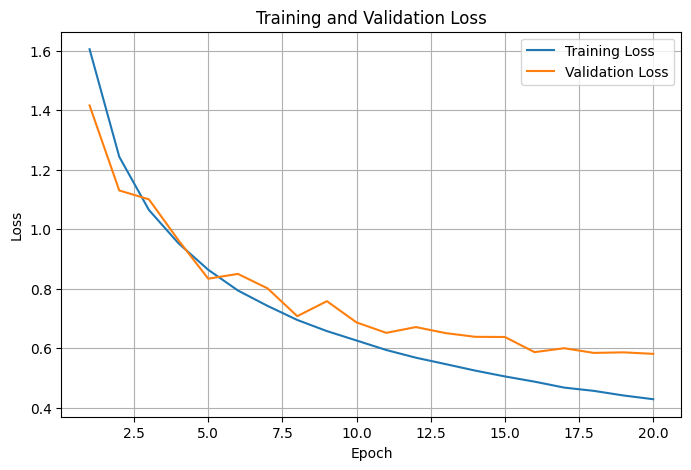

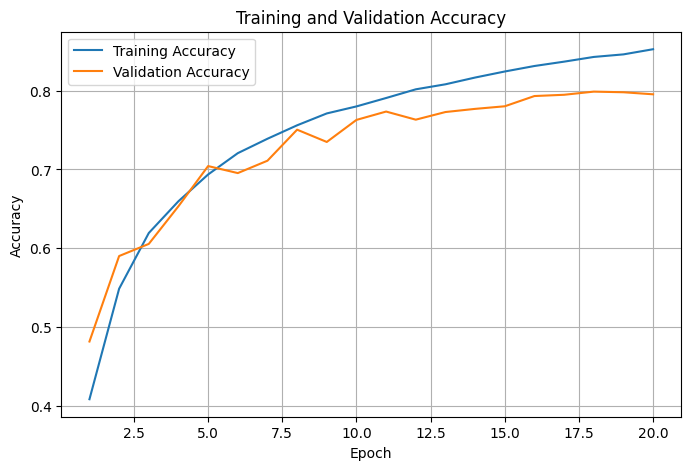

In [38]:
cnn_utils.plot_history(history_densenet4)

In [39]:
test_loss_densenet4, test_accuracy_densenet4 = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss_densenet4:.4f}")
print(f"Test Accuracy: {test_accuracy_densenet4:.2f}%")

Test Loss: 0.5920
Test Accuracy: 0.7949
Test Loss: 0.5920
Test Accuracy: 0.79%


### DenseNet4 — Results and Analysis

DenseNet4 was the third and final model evaluated in the depth experiment. The model contains **4 DenseBlocks**, with **3 DenseLayers in each block**. The growth rate was kept at **16**, and the initial number of channels remained **64**. Therefore, the only architectural change from DenseNet3 was the addition of one more DenseBlock.

The model started with a training accuracy of **40.83%** and a validation accuracy of **48.16%** in the first epoch. Both increased throughout training. By epoch 10, the training accuracy had reached **77.80%**, while the validation accuracy was **76.29%**. At the end of epoch 20, the training accuracy reached **85.26%**, while the validation accuracy was **79.54%**.

Training loss decreased from **1.6051** in the first epoch to **0.4280** at epoch 20. Validation loss also decreased from **1.4160** to **0.5806**.

The loss curves show a clear downward trend for both training and validation loss. Training loss continued to decrease throughout the 20 epochs, while validation loss became more stable during the later part of training. The validation loss reached **0.5806** at epoch 20, which was its lowest value during the run.

The accuracy curves show that training accuracy continued to increase throughout the experiment. Validation accuracy also improved overall, although it fluctuated during the later epochs. The highest validation accuracy during training was **79.80% at epoch 19**, before falling slightly to **79.54% at epoch 20**.

The final training and validation results were:

| Metric | Training | Validation |
|---|---:|---:|
| Loss | 0.4280 | 0.5806 |
| Accuracy | 85.26% | 79.54% |

The difference between the final training accuracy and validation accuracy was:

**85.26% − 79.54% = 5.72 percentage points.**

This gap is larger than the corresponding gap for DenseNet3, which was **3.36 percentage points**. This indicates that DenseNet4 was fitting the training data more strongly than DenseNet3, while the improvement in validation performance was smaller.

After training, DenseNet4 was evaluated on the untouched CIFAR-10 test set. The model achieved a **test loss of 0.5920** and a **test accuracy of 79.49%**.

The validation and test accuracies were almost identical:

- Validation accuracy: **79.54%**
- Test accuracy: **79.49%**
- Difference: **0.05 percentage points**

This shows that the final validation result was very close to the performance obtained on the unseen test set.

Comparing DenseNet4 with DenseNet3 shows that adding the fourth DenseBlock continued to improve performance, but the improvement was much smaller than the improvement obtained when moving from DenseNet2 to DenseNet3.

| Model | Dense Blocks | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet2 | 2 | 74.70% | 72.72% | 72.63% |
| DenseNet3 | 3 | 81.72% | 78.36% | 78.40% |
| DenseNet4 | 4 | 85.26% | 79.54% | 79.49% |

From DenseNet2 to DenseNet3, test accuracy increased by **5.77 percentage points**:

**78.40% − 72.63% = 5.77 percentage points**

From DenseNet3 to DenseNet4, the increase was only **1.09 percentage points**:

**79.49% − 78.40% = 1.09 percentage points**

The total improvement from DenseNet2 to DenseNet4 was therefore **6.86 percentage points**.

The results show that increasing the number of DenseBlocks improved test performance across the three models, but the size of the improvement decreased as the network became deeper. At the same time, the training-validation gap increased from **1.98 percentage points** in DenseNet2 to **3.36 percentage points** in DenseNet3 and finally **5.72 percentage points** in DenseNet4.

For this experiment, DenseNet4 produced the highest test accuracy at **79.49%**. However, the results also show that the additional fourth DenseBlock produced a much smaller test improvement than the previous increase in depth, while producing a larger separation between training and validation accuracy.

This gives us the main observation from the depth experiment: increasing the number of DenseBlocks from 2 to 3 produced a substantial improvement in test performance, while increasing it from 3 to 4 produced a smaller additional improvement and a larger training-validation gap.

# Experiment 2 — Growth Rate

The second DenseNet experiment investigates the effect of the **growth rate** on classification performance.

In DenseNet, the growth rate determines the number of new feature maps that each DenseLayer contributes to the dense block. A larger growth rate means that every new layer adds more feature maps to the existing representation, causing the number of channels within the block to grow more quickly.

For this experiment, the overall network depth is kept fixed at **3 DenseBlocks**, with **3 DenseLayers in each block**. The initial number of channels is also fixed at **64**. The only architectural variable being changed is the growth rate.

### Experimental configurations

| Model | Dense Blocks | Layers per Block | Growth Rate | Initial Channels |
|---|---:|---:|---:|---:|
| DenseNet3-Narrow | 3 | 3 | 8 | 64 |
| DenseNet3-Base | 3 | 3 | 16 | 64 |
| DenseNet3-Wide | 3 | 3 | 24 | 64 |

### Controlled variables

The following settings remain constant across the three models:

- Dataset: CIFAR-10
- Input size: 32 × 32 RGB images
- Number of DenseBlocks: 3
- DenseLayers per block: 3
- Initial channels: 64
- Batch size: 64
- Optimizer: SGD
- Learning rate: 0.01
- Momentum: 0.9
- Loss function: CrossEntropyLoss
- Epochs: 20
- Training augmentation: RandomHorizontalFlip
- Official CIFAR-10 test set: kept untouched until final evaluation

### What this experiment investigates

The main question is:

> **How does changing the growth rate affect the performance of a fixed-depth DenseNet?**

The growth rate controls how many new feature maps are added by each DenseLayer. Therefore, increasing the growth rate increases the number of channels available to later layers within each DenseBlock.

By comparing growth rates of **8, 16, and 24**, we can observe whether giving each DenseLayer more capacity improves the model's ability to learn useful representations and generalize to unseen CIFAR-10 images.

The depth of the network is kept fixed so that changes in performance can be associated primarily with the growth rate rather than with adding or removing DenseBlocks.

### DenseNet3-Narrow — Growth Rate 8

DenseNet3-Narrow uses the same three-DenseBlock architecture used in the previous depth experiment, but the growth rate is reduced from **16 to 8**.

Each DenseLayer therefore adds only 8 new feature maps to the representation within its DenseBlock.

The configuration is:

- DenseBlocks: 3
- DenseLayers per block: 3
- Growth rate: 8
- Initial channels: 64

This configuration provides the lower-capacity model for the growth-rate experiment. Its results will be compared with the Base configuration using a growth rate of 16 and the Wide configuration using a growth rate of 24.

In [40]:
model = DenseNet(
    num_blocks=3,
    num_layers=3,
    growth_rate=8,
    init_channels=64
)

print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(72, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(80, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
        (0)

In [41]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [42]:
model, history_densenet3_narrow = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7468 | Train Acc: 0.3580 | Val Loss: 1.5257 | Val Acc: 0.4477
Epoch [2/20] Train Loss: 1.4595 | Train Acc: 0.4653 | Val Loss: 1.4105 | Val Acc: 0.4907
Epoch [3/20] Train Loss: 1.3064 | Train Acc: 0.5263 | Val Loss: 1.2758 | Val Acc: 0.5360
Epoch [4/20] Train Loss: 1.2030 | Train Acc: 0.5669 | Val Loss: 1.2040 | Val Acc: 0.5618
Epoch [5/20] Train Loss: 1.1328 | Train Acc: 0.5940 | Val Loss: 1.1311 | Val Acc: 0.5895
Epoch [6/20] Train Loss: 1.0810 | Train Acc: 0.6110 | Val Loss: 1.0782 | Val Acc: 0.6141
Epoch [7/20] Train Loss: 1.0296 | Train Acc: 0.6330 | Val Loss: 1.0243 | Val Acc: 0.6290
Epoch [8/20] Train Loss: 0.9874 | Train Acc: 0.6473 | Val Loss: 0.9483 | Val Acc: 0.6627
Epoch [9/20] Train Loss: 0.9468 | Train Acc: 0.6610 | Val Loss: 0.9818 | Val Acc: 0.6457
Epoch [10/20] Train Loss: 0.9100 | Train Acc: 0.6777 | Val Loss: 0.9409 | Val Acc: 0.6640
Epoch [11/20] Train Loss: 0.8812 | Train Acc: 0.6853 | Val Loss: 0.9022 | Val Acc: 0.6779
Epoch [12/20] Train

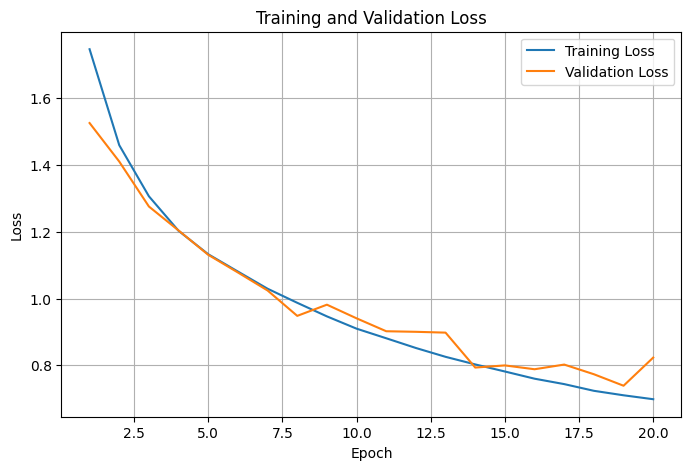

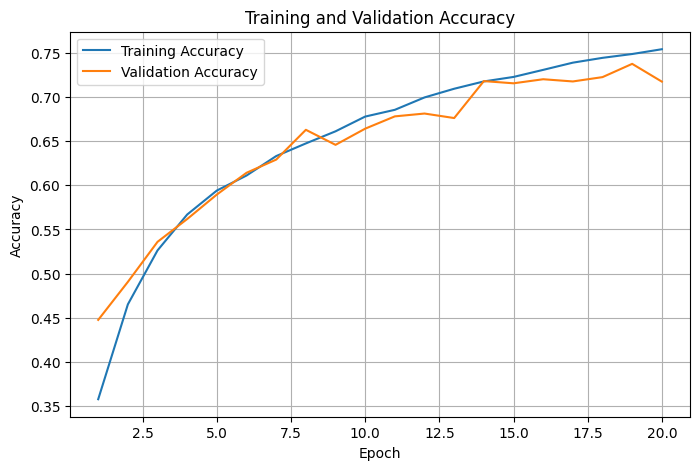

In [43]:
cnn_utils.plot_history(history_densenet3_narrow)

In [44]:
test_loss_densenet3_narrow, test_accuracy_densenet3_narrow = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss_densenet3_narrow:.4f}")
print(f"Test Accuracy: {test_accuracy_densenet3_narrow:.2f}%")

Test Loss: 0.8713
Test Accuracy: 0.7110
Test Loss: 0.8713
Test Accuracy: 0.71%


### DenseNet3-Narrow — Results and Analysis

DenseNet3-Narrow was trained with **3 DenseBlocks**, with **3 DenseLayers in each block**, and a growth rate of **8**. The initial number of channels remained fixed at **64**. The model was therefore identical in depth to DenseNet3 from the previous experiment, with the growth rate being the main architectural difference.

The model started with a training accuracy of **35.80%** in the first epoch and a validation accuracy of **44.77%**. Both training and validation accuracy increased throughout the experiment. By epoch 10, training accuracy had reached **67.77%**, while validation accuracy was **66.40%**. At epoch 20, training accuracy reached **75.39%**, while validation accuracy finished at **71.72%**.

Training loss decreased from **1.7468** in the first epoch to **0.6987** at epoch 20. Validation loss decreased from **1.5257** to **0.8234**. The validation loss generally followed the downward trend of the training loss, although there were several fluctuations during the later epochs. In particular, validation loss increased from **0.7931 at epoch 19** to **0.8234 at epoch 20**, while validation accuracy also decreased from **73.73%** to **71.72%**.

The final training and validation results were:

| Metric | Training | Validation |
|---|---:|---:|
| Loss | 0.6987 | 0.8234 |
| Accuracy | 75.39% | 71.72% |

The difference between the final training accuracy and validation accuracy was:

**75.39% − 71.72% = 3.67 percentage points.**

This shows that the model had a noticeable training-validation gap by the end of training, although the gap was not extremely large.

The model was then evaluated on the untouched CIFAR-10 test set. DenseNet3-Narrow achieved a **test loss of 0.8713** and a **test accuracy of 71.10%**.

The test accuracy was slightly lower than the final validation accuracy:

- Validation accuracy: **71.72%**
- Test accuracy: **71.10%**
- Difference: **0.62 percentage points**

To understand the effect of the growth rate, DenseNet3-Narrow can also be compared with the **DenseNet3 Base configuration** from the previous depth experiment. Both models use 3 DenseBlocks, 3 DenseLayers per block, and 64 initial channels. The important difference is the growth rate: DenseNet3-Narrow uses **8**, while DenseNet3 Base uses **16**.

| Model | Growth Rate | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet3-Narrow | 8 | 75.39% | 71.72% | 71.10% |
| DenseNet3-Base | 16 | 81.72% | 78.36% | 78.40% |

Increasing the growth rate from **8 to 16** is therefore associated with an increase of **7.30 percentage points in test accuracy** in these two runs.

The Narrow configuration provides the lower-capacity reference point for the growth-rate experiment. The next model, DenseNet3-Base, will use a growth rate of **16**, followed by DenseNet3-Wide with a growth rate of **24**. Comparing all three configurations will allow us to see whether increasing the number of new feature maps continues to improve performance or whether the gains begin to level off.

### DenseNet3-Wide — Growth Rate 24

DenseNet3-Wide is the third and final model in the growth-rate experiment. It keeps the network depth fixed at **3 DenseBlocks**, with **3 DenseLayers in each block**, but increases the growth rate to **24**.

The initial number of channels remains fixed at **64**. Therefore, compared with DenseNet3-Narrow and DenseNet3-Base, the main architectural difference in this model is the number of new feature maps produced by each DenseLayer.

The configuration is:

- DenseBlocks: 3
- DenseLayers per block: 3
- Growth rate: 24
- Initial channels: 64

With a growth rate of 24, every DenseLayer adds 24 new feature maps to the feature representation within its dense block. This allows later layers in the block to receive a larger collection of previously generated features.

The purpose of this configuration is to determine whether increasing the growth rate beyond the base value of 16 continues to improve classification performance, or whether the additional feature capacity produces smaller gains or a larger training-validation gap.

The training and evaluation conditions remain unchanged from the other two growth-rate configurations.

In [45]:
model = DenseNet(
    num_blocks=3,
    num_layers=3,
    growth_rate=24,
    init_channels=64
)

print(model)

DenseNet(
  (initial): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (blocks): ModuleList(
    (0): DenseBlock(
      (layers): ModuleList(
        (0): DenseLayer(
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(64, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn): BatchNorm2d(88, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(88, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (2): DenseLayer(
          (bn): BatchNorm2d(112, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv): Conv2d(112, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
    )
    (1): DenseBlock(
      (layers): ModuleList(
      

In [46]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [47]:
model, history_densenet3_wide = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6451 | Train Acc: 0.3959 | Val Loss: 1.4946 | Val Acc: 0.4535
Epoch [2/20] Train Loss: 1.2858 | Train Acc: 0.5366 | Val Loss: 1.2879 | Val Acc: 0.5269
Epoch [3/20] Train Loss: 1.1119 | Train Acc: 0.6029 | Val Loss: 1.0824 | Val Acc: 0.6081
Epoch [4/20] Train Loss: 0.9984 | Train Acc: 0.6430 | Val Loss: 0.9775 | Val Acc: 0.6495
Epoch [5/20] Train Loss: 0.9100 | Train Acc: 0.6746 | Val Loss: 1.0463 | Val Acc: 0.6307
Epoch [6/20] Train Loss: 0.8458 | Train Acc: 0.6995 | Val Loss: 0.8970 | Val Acc: 0.6786
Epoch [7/20] Train Loss: 0.7938 | Train Acc: 0.7175 | Val Loss: 0.8537 | Val Acc: 0.6989
Epoch [8/20] Train Loss: 0.7418 | Train Acc: 0.7368 | Val Loss: 0.8531 | Val Acc: 0.6981
Epoch [9/20] Train Loss: 0.6928 | Train Acc: 0.7549 | Val Loss: 0.7156 | Val Acc: 0.7474
Epoch [10/20] Train Loss: 0.6568 | Train Acc: 0.7673 | Val Loss: 0.7571 | Val Acc: 0.7383
Epoch [11/20] Train Loss: 0.6223 | Train Acc: 0.7809 | Val Loss: 0.7161 | Val Acc: 0.7443
Epoch [12/20] Train

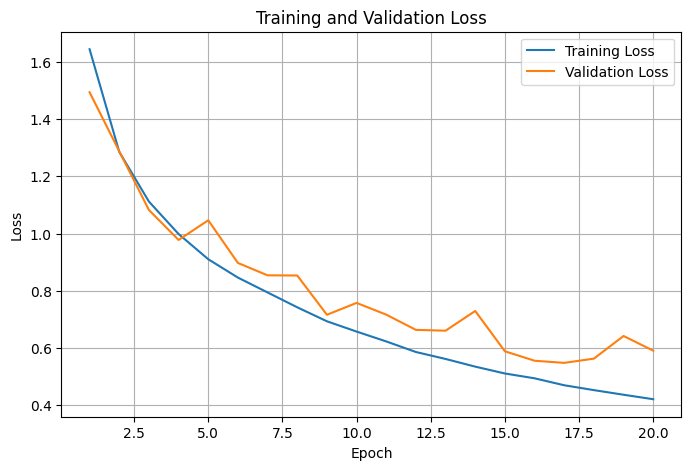

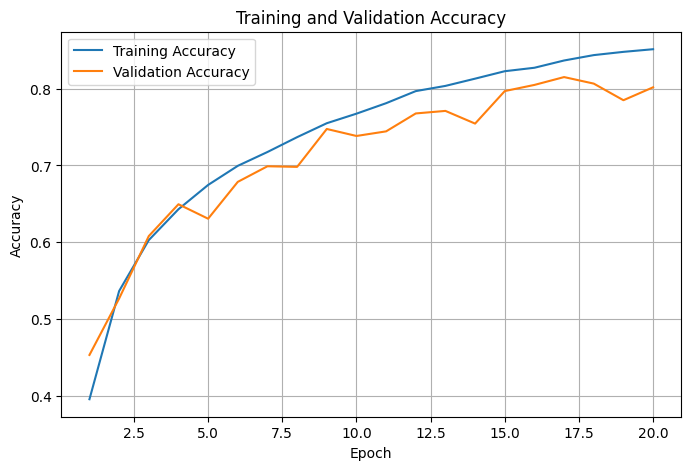

In [48]:
cnn_utils.plot_history(history_densenet3_wide)

In [49]:
test_loss_densenet3_wide, test_accuracy_densenet3_wide = cnn_utils.test_model(
    model=model,
    test_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print(f"Test Loss: {test_loss_densenet3_wide:.4f}")
print(f"Test Accuracy: {test_accuracy_densenet3_wide:.2f}%")

Test Loss: 0.5963
Test Accuracy: 0.8018
Test Loss: 0.5963
Test Accuracy: 0.80%


### DenseNet3-Wide — Results and Analysis

DenseNet3-Wide was the final model evaluated in the growth-rate experiment. It uses 3 DenseBlocks, with 3 DenseLayers in each block, and a growth rate of 24. The initial number of channels remained fixed at 64.

The depth of the network was therefore kept identical to the previous two growth-rate configurations. The only architectural variable changed in this experiment was the growth rate.

The model started with a training accuracy of 39.59% and a validation accuracy of 45.35% in the first epoch. Both increased as training progressed. By epoch 10, the training accuracy had reached 76.73%, while the validation accuracy was 73.83%. At the end of epoch 20, the training accuracy reached 85.11%, while the validation accuracy reached 80.16%.

Training loss decreased from 1.6451 in the first epoch to 0.4200 at the end of training. Validation loss decreased from 1.4946 to 0.5900.

The curves show a generally consistent decrease in both training and validation loss. There were some fluctuations in validation loss, particularly around epochs 5, 9, 14, and 19, but the overall trend remained downward. Validation accuracy also fluctuated during training, but continued to improve overall and finished at 80.16%.

The final training and validation results were:

| Metric | Training | Validation |
|---|---:|---:|
| Loss | 0.4200 | 0.5900 |
| Accuracy | 85.11% | 80.16% |

The difference between the final training accuracy and validation accuracy was:

85.11% − 80.16% = 4.95 percentage points.

The model was then evaluated on the untouched CIFAR-10 test set. DenseNet3-Wide achieved a test loss of 0.5963 and a test accuracy of 80.18%.

The validation and test results were almost identical:

- Validation accuracy: 80.16%
- Test accuracy: 80.18%
- Difference: 0.02 percentage points

This shows that the validation result closely represented the model's performance on the unseen test set for this run.

The three growth-rate configurations can now be compared under the same depth and training conditions:

| Model | Growth Rate | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet3-Narrow | 8 | 75.39% | 71.72% | 71.10% |
| DenseNet3-Base | 16 | 81.72% | 78.36% | 78.40% |
| DenseNet3-Wide | 24 | 85.11% | 80.16% | 80.18% |

Increasing the growth rate from 8 to 16 increased test accuracy from 71.10% to 78.40%. This is an improvement of 7.30 percentage points.

Increasing the growth rate from 16 to 24 increased test accuracy from 78.40% to 80.18%. This gives an additional improvement of 1.78 percentage points.

The total improvement from growth rate 8 to growth rate 24 was therefore 9.08 percentage points.

Training accuracy followed the same general pattern. It increased from 75.39% with growth rate 8 to 81.72% with growth rate 16 and then to 85.11% with growth rate 24.

The results show that increasing the growth rate improved both training performance and held-out performance across the three configurations. However, the size of the test improvement became smaller when moving from growth rate 16 to 24.

The growth-rate experiment is now complete. The next step is to compare the three configurations together and determine what the results from this experiment show about the effect of growth rate on this DenseNet architecture.

# DenseNet — Overall Experimental Summary

The DenseNet experiment was designed to study how two architectural properties affect image-classification performance on CIFAR-10:

1. Network depth, measured by the number of DenseBlocks.
2. Growth rate, which determines how many new feature maps each DenseLayer contributes to a DenseBlock.

The purpose of the experiment was not to search for the highest possible CIFAR-10 accuracy. Instead, the objective was to understand how changing important DenseNet architectural parameters affects training behavior, validation performance, generalization, and test performance.

All models were trained under the same general experimental conditions so that the architectural changes could be compared directly.

## Experimental Setup

The models were trained on the CIFAR-10 dataset using 32 × 32 RGB images.

The main training settings were kept constant throughout the experiments:

| Setting | Configuration |
|---|---|
| Dataset | CIFAR-10 |
| Input size | 32 × 32 RGB |
| Batch size | 64 |
| Optimizer | SGD |
| Learning rate | 0.01 |
| Momentum | 0.9 |
| Loss function | CrossEntropyLoss |
| Training epochs | 20 |
| Training augmentation | RandomHorizontalFlip |
| Initial channels | 64 |
| Test set | Untouched until final evaluation |

The DenseNet architecture used three main components:

- DenseLayer
- DenseBlock
- TransitionLayer

Within a DenseBlock, feature maps produced by previous layers were concatenated along the channel dimension and made available to subsequent layers. The TransitionLayer was used between DenseBlocks to reduce the number of channels and reduce the spatial dimensions.

The experiments were divided into two parts so that depth and growth rate could be studied separately.

# Experiment 1 — Depth

The first experiment investigated the effect of increasing the number of DenseBlocks.

The number of DenseLayers inside each block was fixed at 3, the growth rate was fixed at 16, and the initial number of channels was fixed at 64.

The only architectural variable was therefore the number of DenseBlocks.

| Model | DenseBlocks | DenseLayers per Block | Growth Rate | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet2 | 2 | 3 | 16 | 72.63% |
| DenseNet3 | 3 | 3 | 16 | 78.40% |
| DenseNet4 | 4 | 3 | 16 | 79.49% |

## DenseNet2

DenseNet2 contained 2 DenseBlocks.

It achieved:

- Training accuracy: 74.70%
- Validation accuracy: 72.72%
- Test accuracy: 72.63%
- Training loss: 0.7126
- Validation loss: 0.7646
- Test loss: 0.7808

The training and validation curves remained relatively close during training. By the end of the 20 epochs, the difference between training and validation accuracy was 1.98 percentage points.

The test accuracy of 72.63% provided the starting point for the depth experiment.

## DenseNet3

DenseNet3 increased the number of DenseBlocks from 2 to 3 while keeping the other architectural parameters unchanged.

It achieved:

- Training accuracy: 81.72%
- Validation accuracy: 78.36%
- Test accuracy: 78.40%
- Training loss: 0.5259
- Validation loss: 0.6122
- Test loss: 0.6204

The increase from DenseNet2 to DenseNet3 produced a substantial improvement.

Test accuracy increased from 72.63% to 78.40%.

This represents an improvement of:

78.40% − 72.63% = 5.77 percentage points.

Training accuracy also increased by 7.02 percentage points, while validation accuracy increased by 5.64 percentage points.

The training-validation accuracy gap increased from 1.98 percentage points in DenseNet2 to 3.36 percentage points in DenseNet3, but the model still showed a substantial improvement on the validation and test sets.

## DenseNet4

DenseNet4 increased the number of DenseBlocks from 3 to 4.

It achieved:

- Training accuracy: 85.26%
- Validation accuracy: 79.54%
- Test accuracy: 79.49%
- Training loss: 0.4280
- Validation loss: 0.5806
- Test loss: 0.5920

DenseNet4 continued the improvement observed with increasing depth, but the improvement was much smaller than the increase obtained when moving from DenseNet2 to DenseNet3.

Test accuracy increased from 78.40% with DenseNet3 to 79.49% with DenseNet4.

This represents an additional improvement of:

79.49% − 78.40% = 1.09 percentage points.

The total improvement from DenseNet2 to DenseNet4 was 6.86 percentage points.

At the same time, the training-validation gap increased to 5.72 percentage points:

85.26% − 79.54% = 5.72 percentage points.

Therefore, although DenseNet4 continued to improve test performance, it also showed a larger separation between training and validation performance.

## Depth Experiment Comparison

The complete depth results are:

| Model | DenseBlocks | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet2 | 2 | 74.70% | 72.72% | 72.63% |
| DenseNet3 | 3 | 81.72% | 78.36% | 78.40% |
| DenseNet4 | 4 | 85.26% | 79.54% | 79.49% |

The results show that increasing the number of DenseBlocks improved test performance across all three configurations.

However, the size of the improvement decreased as the network became deeper.

The increase from 2 to 3 DenseBlocks produced a 5.77 percentage-point improvement in test accuracy.

The increase from 3 to 4 DenseBlocks produced only a 1.09 percentage-point improvement.

At the same time, the training accuracy continued to increase substantially:

74.70% → 81.72% → 85.26%.

This means that the deeper models were increasingly able to fit the training data, while the corresponding improvement on the test set became smaller.

The training-validation accuracy gap also increased:

- DenseNet2: 1.98 percentage points
- DenseNet3: 3.36 percentage points
- DenseNet4: 5.72 percentage points

Based on these experiments, increasing the number of DenseBlocks was beneficial, particularly when moving from 2 to 3 blocks. However, the results from 4 blocks show diminishing improvement in test accuracy together with a larger training-validation gap.

# Experiment 2 — Growth Rate

The second experiment investigated the effect of the DenseNet growth rate.

For this experiment, the depth was fixed at 3 DenseBlocks, with 3 DenseLayers per block and 64 initial channels.

Only the growth rate was changed.

| Model | DenseBlocks | DenseLayers per Block | Growth Rate | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet3-Narrow | 3 | 3 | 8 | 71.10% |
| DenseNet3-Base | 3 | 3 | 16 | 78.40% |
| DenseNet3-Wide | 3 | 3 | 24 | 80.18% |

## DenseNet3-Narrow

DenseNet3-Narrow used a growth rate of 8.

It achieved:

- Training accuracy: 75.39%
- Validation accuracy: 71.72%
- Test accuracy: 71.10%
- Training loss: 0.6987
- Validation loss: 0.8234
- Test loss: 0.8713

The lower growth rate resulted in lower training accuracy as well as lower validation and test accuracy.

The training-validation accuracy gap at the end of training was 3.67 percentage points.

The test accuracy of 71.10% provided the lower-capacity reference point for the growth-rate experiment.

## DenseNet3-Base

DenseNet3-Base used a growth rate of 16.

Its results were:

- Training accuracy: 81.72%
- Validation accuracy: 78.36%
- Test accuracy: 78.40%
- Training loss: 0.5259
- Validation loss: 0.6122
- Test loss: 0.6204

This was the same DenseNet3 configuration used in the depth experiment.

Compared with the growth-rate-8 model, increasing the growth rate from 8 to 16 produced a substantial increase in test accuracy.

Test accuracy increased from 71.10% to 78.40%.

The improvement was:

78.40% − 71.10% = 7.30 percentage points.

## DenseNet3-Wide

DenseNet3-Wide increased the growth rate from 16 to 24 while keeping the network depth unchanged.

It achieved:

- Training accuracy: 85.11%
- Validation accuracy: 80.16%
- Test accuracy: 80.18%
- Training loss: 0.4200
- Validation loss: 0.5900
- Test loss: 0.5963

The increase from growth rate 16 to 24 produced another improvement in test performance.

Test accuracy increased from 78.40% to 80.18%.

The improvement was:

80.18% − 78.40% = 1.78 percentage points.

Therefore, although increasing the growth rate continued to improve performance, the improvement from 16 to 24 was substantially smaller than the improvement from 8 to 16.

## Growth Rate Experiment Comparison

The complete results are:

| Model | Growth Rate | Train Accuracy | Validation Accuracy | Test Accuracy |
|---|---:|---:|---:|---:|
| DenseNet3-Narrow | 8 | 75.39% | 71.72% | 71.10% |
| DenseNet3-Base | 16 | 81.72% | 78.36% | 78.40% |
| DenseNet3-Wide | 24 | 85.11% | 80.16% | 80.18% |

The results show a clear increase in performance as the growth rate increased from 8 to 24.

Test accuracy changed as follows:

71.10% → 78.40% → 80.18%.

The largest improvement occurred between growth rates 8 and 16, where test accuracy increased by 7.30 percentage points.

The increase from 16 to 24 produced a much smaller improvement of 1.78 percentage points.

Training accuracy also increased consistently:

75.39% → 81.72% → 85.11%.

This shows that increasing the growth rate increased the amount of representational capacity available to the model. However, the improvement in held-out performance did not increase at the same rate as the training performance.

# Overall DenseNet Findings

The two experiments examined different architectural aspects of DenseNet.

The depth experiment changed the number of DenseBlocks while keeping the growth rate fixed at 16.

The growth-rate experiment changed the number of new feature maps added by each DenseLayer while keeping the depth fixed at 3 DenseBlocks.

The results from both experiments showed that increasing architectural capacity improved performance on CIFAR-10, but the size of the improvement depended on where the change was made.

For depth, the test accuracy increased:

72.63% → 78.40% → 79.49%

as the number of DenseBlocks increased from 2 to 4.

For growth rate, the test accuracy increased:

71.10% → 78.40% → 80.18%

as the growth rate increased from 8 to 24.

The largest individual improvement observed in these experiments came from increasing the growth rate from 8 to 16, which improved test accuracy by 7.30 percentage points.

For depth, the largest improvement came from increasing the number of DenseBlocks from 2 to 3, which improved test accuracy by 5.77 percentage points.

In both experiments, the later increase produced a smaller improvement than the first increase.

For depth:

2 → 3 blocks: +5.77 percentage points

3 → 4 blocks: +1.09 percentage points

For growth rate:

8 → 16: +7.30 percentage points

16 → 24: +1.78 percentage points

This pattern indicates that increasing model capacity was useful within the range tested, but the additional benefit became smaller at the higher-capacity configuration.

The experiments also showed increasing differences between training and validation accuracy as model capacity increased in several cases. In the depth experiment, the training-validation gap increased from 1.98 percentage points for DenseNet2 to 3.36 percentage points for DenseNet3 and 5.72 percentage points for DenseNet4.

This means that the deeper models were increasingly capable of fitting the training data, while the improvement on unseen data was smaller.

The growth-rate experiment showed a similar relationship. Increasing the growth rate increased training accuracy from 75.39% to 81.72% and then to 85.11%. Test accuracy also increased, but the improvement became smaller when moving from growth rate 16 to 24.

Overall, the DenseNet experiments demonstrated how architectural capacity can be changed in two different ways: by increasing the number of DenseBlocks or by increasing the growth rate. Both changes affected the model's ability to learn from the training data and its performance on unseen data.

The experiments also demonstrated why architectural changes should be evaluated using validation and test performance rather than training accuracy alone. A deeper or wider model can achieve higher training accuracy without producing an equally large improvement on unseen data.

For this project, the main value of the DenseNet experiment was therefore not simply identifying the configuration with the highest test accuracy. It was observing how changing specific architectural parameters affected learning behavior, generalization, and the relationship between model capacity and performance.